# Proyecto ML — Hotel Booking Cancellation

Pipeline completo de Machine Learning para predecir la cancelación de reservas hoteleras.

**Autores:** Nil Coronado, Lucía Vetrano

**Notebook final del pipeline.** Integra el trabajo de EDA, preprocesado y modelado desarrollado en `src/notebooks/`. Se ejecuta de principio a fin sin intervención manual.

## 1 · Business Case & Problem Definition

**Problema de negocio.** Las cancelaciones de última hora dejan habitaciones vacías sin margen para revenderlas, con impacto económico directo en la gestión de ingresos (*revenue management*) de los hoteles.

**Objetivo de modelado.** Clasificación binaria supervisada: predecir `is_canceled` (0 = no cancela, 1 = cancela) para anticipar el riesgo de cancelación antes de la fecha de llegada.

**Plan de acción.** Un modelo fiable permite al hotel actuar de forma diferenciada según el riesgo de cada reserva: overbooking controlado, políticas de depósito y campañas de reconfirmación dirigidas a las reservas de mayor riesgo.

**Datos.** [Hotel Booking Demand](https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand) (Kaggle, público) — 119.390 reservas de dos hoteles (resort y ciudad) entre 2015 y 2017.

## 2 · Data Understanding — División Train / Test

La separación train/test se realiza **antes** de cualquier exploración, mediante `src/utils/split_data.py`, con `random_state=42` y `stratify` sobre la variable target, para que ambos conjuntos mantengan la misma proporción de cancelaciones. El conjunto de test no se vuelve a tocar hasta la evaluación final del modelo (Sección 6).

In [1]:
import subprocess
# Descomentar para regenerar train.csv / test.csv desde el CSV bruto de Kaggle:
# subprocess.run(["python", "src/utils/split_data.py"])
print("Split ya generado en src/data_sample/train.csv y test.csv (random_state=42, stratify=is_canceled)")

Split ya generado en src/data_sample/train.csv y test.csv (random_state=42, stratify=is_canceled)


# EDA Dirigido — Hotel Booking Cancellation

EDA sobre `train.csv` (95.512 filas) orientado al modelado de la variable target `is_canceled`. El conjunto de test no se toca en ningún momento de este análisis.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
IMG_DIR = 'src/img'

df = pd.read_csv('src/data_sample/train.csv')
df.shape

(95512, 32)

## Paso 1: Exploratorio inicial

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 95512 entries, 0 to 95511
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           95512 non-null  str    
 1   is_canceled                     95512 non-null  int64  
 2   lead_time                       95512 non-null  int64  
 3   arrival_date_year               95512 non-null  int64  
 4   arrival_date_month              95512 non-null  str    
 5   arrival_date_week_number        95512 non-null  int64  
 6   arrival_date_day_of_month       95512 non-null  int64  
 7   stays_in_weekend_nights         95512 non-null  int64  
 8   stays_in_week_nights            95512 non-null  int64  
 9   adults                          95512 non-null  int64  
 10  children                        95508 non-null  float64
 11  babies                          95512 non-null  int64  
 12  meal                            95512 non-n

In [4]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,City Hotel,0,20,2017,February,6,7,0,2,1,...,No Deposit,195.0,417.0,0,Transient,98.0,0,0,Check-Out,2017-02-09
1,City Hotel,0,8,2016,March,11,9,0,3,2,...,No Deposit,NaN,NaN,0,Transient-Party,100.0,0,0,Check-Out,2016-03-12
2,City Hotel,1,93,2017,April,14,6,0,3,2,...,Non Refund,170.0,NaN,0,Transient,95.0,0,0,Canceled,2017-01-03
3,Resort Hotel,0,90,2015,September,39,23,4,10,2,...,No Deposit,2.0,NaN,0,Contract,54.0,0,0,Check-Out,2015-10-07
4,City Hotel,0,8,2017,August,32,9,0,1,1,...,No Deposit,NaN,91.0,0,Transient,80.0,0,0,Check-Out,2017-08-10


## Paso 2: Tabla de variables y missings

Variable target: **`is_canceled`** (0 = no cancelada, 1 = cancelada).

In [5]:
missings = df.isna().sum()
missings = missings[missings > 0].sort_values(ascending=False)
missings_pct = (missings / len(df) * 100).round(2)
pd.DataFrame({'missings': missings, 'pct': missings_pct})

,missings,pct
company,90111,94.35
agent,13034,13.65
country,391,0.41
children,4,0.00


**Observaciones sobre missings:**
- `company` (94.3%) y `agent` (13.6%): el missing es informativo — significa que la reserva no vino a través de agencia/compañía. Se tratarán como categoría/indicador, no se imputará con media.
- `country` (0.4%) y `children` (0.004%): missings residuales, imputables por moda/mediana.

**Alerta de data leakage (importante para preprocessing):**
`reservation_status` (Canceled / Check-Out / No-Show) determina `is_canceled` de forma directa y determinista, y `reservation_status_date` es la fecha en la que se conoce ese estado — ambas son posteriores al hecho que queremos predecir. **Deben eliminarse antes de entrenar cualquier modelo**, si no el modelo tendría accuracy ~100% de forma artificial.

## Paso 3: Análisis de la variable target

is_canceled
0    62.958581
1    37.041419
Name: proportion, dtype: float64


/var/folders/bm/zsb22b9d7qdbfwdws5t_yt9w0000gn/T/ipykernel_75221/67924630.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No cancelada', 'Cancelada'])


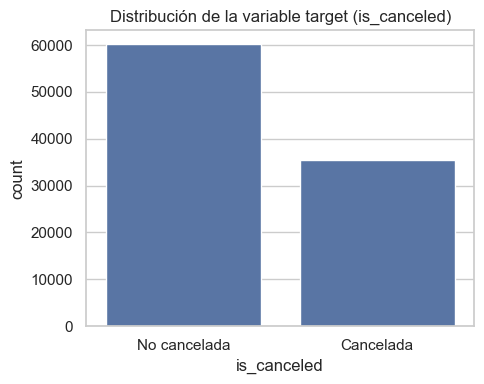

In [6]:
target_counts = df['is_canceled'].value_counts(normalize=True) * 100
print(target_counts)

fig, ax = plt.subplots(figsize=(5,4))
sns.countplot(x='is_canceled', data=df, ax=ax)
ax.set_title('Distribución de la variable target (is_canceled)')
ax.set_xticklabels(['No cancelada', 'Cancelada'])
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/target_balance.png', dpi=100)
plt.show()

**Conclusión:** desbalanceo moderado — 62.96% no canceladas vs. 37.04% canceladas. No es extremo, pero conviene usar `class_weight='balanced'` o estratificar bien la validación cruzada, y evitar Accuracy como métrica única (mejor F1 / Recall / ROC-AUC).

## Paso 4: Relación features vs. target

/var/folders/bm/zsb22b9d7qdbfwdws5t_yt9w0000gn/T/ipykernel_75221/865473220.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No cancelada', 'Cancelada'])


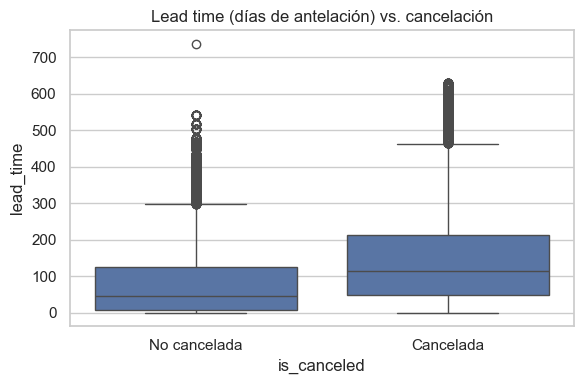

is_canceled
0     45.0
1    113.0
Name: lead_time, dtype: float64

In [7]:
fig, ax = plt.subplots(figsize=(6,4))
sns.boxplot(x='is_canceled', y='lead_time', data=df, ax=ax)
ax.set_title('Lead time (días de antelación) vs. cancelación')
ax.set_xticklabels(['No cancelada', 'Cancelada'])
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/lead_time_vs_target.png', dpi=100)
plt.show()

df.groupby('is_canceled')['lead_time'].median()

deposit_type
Non Refund    0.993770
No Deposit    0.283342
Refundable    0.225564
Name: is_canceled, dtype: float64


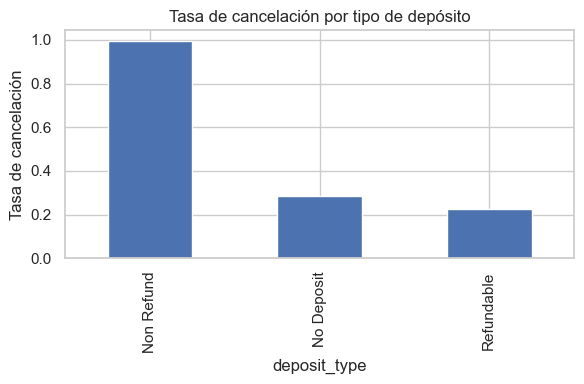

In [8]:
rate_deposit = df.groupby('deposit_type')['is_canceled'].mean().sort_values(ascending=False)
print(rate_deposit)

fig, ax = plt.subplots(figsize=(6,4))
rate_deposit.plot(kind='bar', ax=ax)
ax.set_ylabel('Tasa de cancelación')
ax.set_title('Tasa de cancelación por tipo de depósito')
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/deposit_type_vs_target.png', dpi=100)
plt.show()

**Hallazgo relevante:** las reservas con `deposit_type = 'Non Refund'` tienen una tasa de cancelación mucho más alta que `No Deposit` o `Refundable`. Contraintuitivo a priori (uno esperaría que pagar un depósito no reembolsable desincentive cancelar), pero es un patrón conocido en este dataset y una feature muy predictiva.

market_segment
Undefined        1.000000
Groups           0.610609
Online TA        0.366280
Offline TA/TO    0.342747
Aviation         0.223958
Corporate        0.187263
Direct           0.153754
Complementary    0.135987
Name: is_canceled, dtype: float64


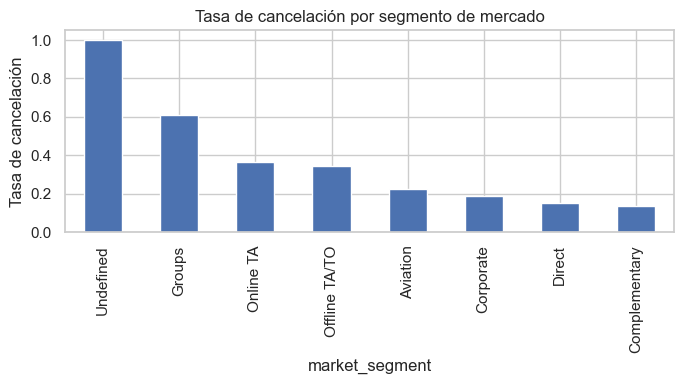

In [9]:
rate_segment = df.groupby('market_segment')['is_canceled'].mean().sort_values(ascending=False)
print(rate_segment)

fig, ax = plt.subplots(figsize=(7,4))
rate_segment.plot(kind='bar', ax=ax)
ax.set_ylabel('Tasa de cancelación')
ax.set_title('Tasa de cancelación por segmento de mercado')
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/market_segment_vs_target.png', dpi=100)
plt.show()

/var/folders/bm/zsb22b9d7qdbfwdws5t_yt9w0000gn/T/ipykernel_75221/3660365193.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No cancelada', 'Cancelada'])


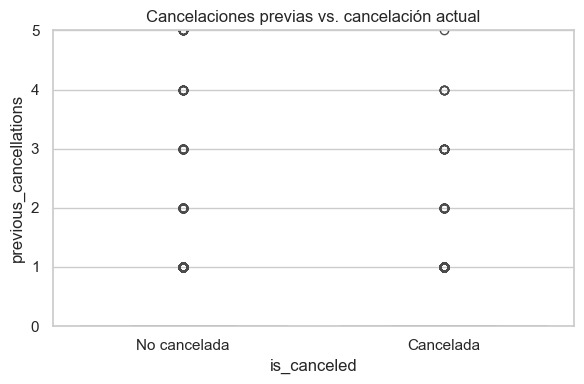

In [10]:
fig, ax = plt.subplots(figsize=(6,4))
sns.boxplot(x='is_canceled', y='previous_cancellations', data=df, ax=ax)
ax.set_title('Cancelaciones previas vs. cancelación actual')
ax.set_xticklabels(['No cancelada', 'Cancelada'])
ax.set_ylim(0, 5)
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/previous_cancellations_vs_target.png', dpi=100)
plt.show()

## Paso 5: Correlaciones entre features numéricas

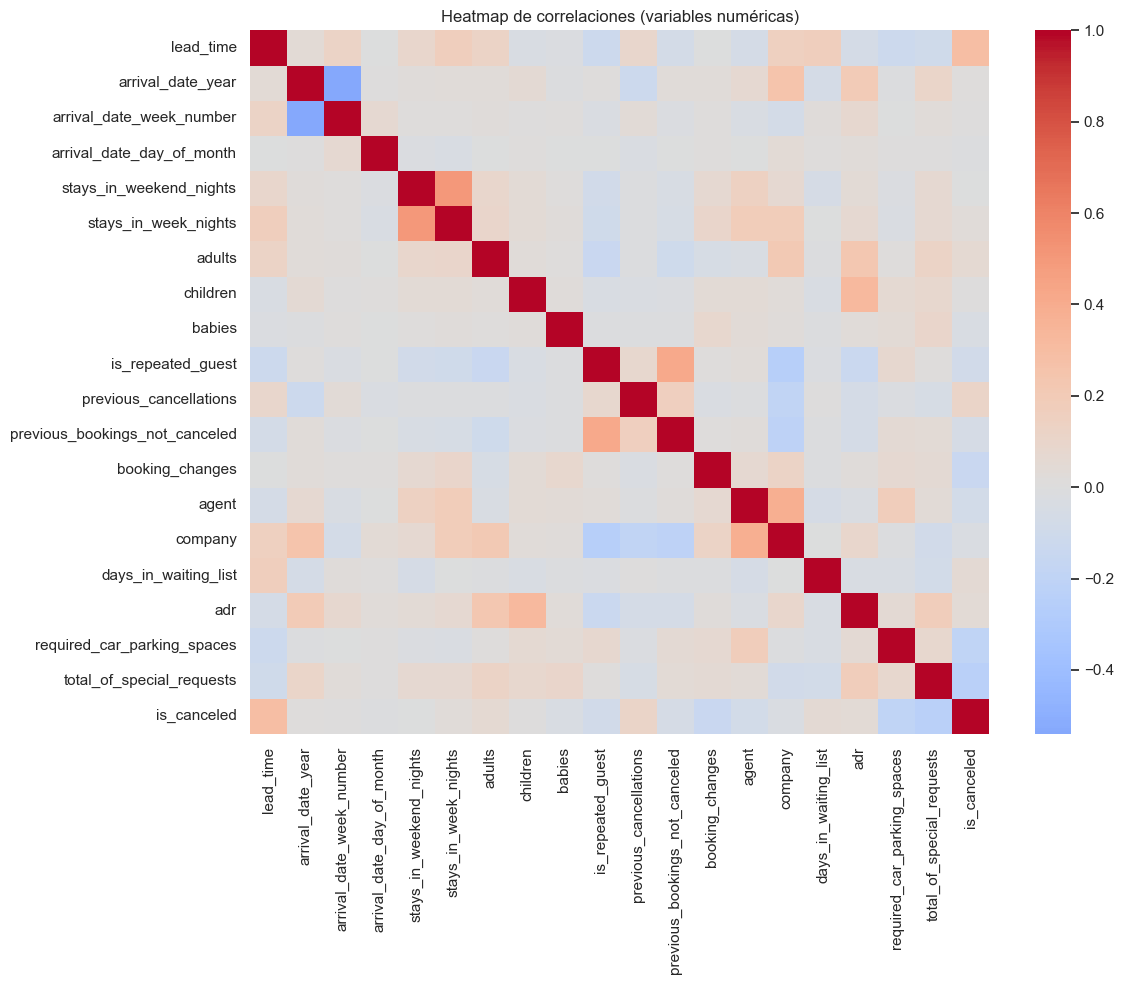

is_canceled                       1.000000
lead_time                         0.293034
previous_cancellations            0.111525
adults                            0.057953
days_in_waiting_list              0.053600
adr                               0.046147
stays_in_week_nights              0.025650
arrival_date_year                 0.017537
arrival_date_week_number          0.007270
children                          0.005648
stays_in_weekend_nights           0.000977
arrival_date_day_of_month        -0.006720
company                          -0.023931
babies                           -0.030659
previous_bookings_not_canceled   -0.057203
agent                            -0.079114
is_repeated_guest                -0.086247
booking_changes                  -0.141886
required_car_parking_spaces      -0.194639
total_of_special_requests        -0.236955
Name: is_canceled, dtype: float64

In [11]:
num_cols = df.select_dtypes(include=[np.number]).columns.drop('is_canceled')
corr = df[num_cols.tolist() + ['is_canceled']].corr()

fig, ax = plt.subplots(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, ax=ax)
ax.set_title('Heatmap de correlaciones (variables numéricas)')
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/correlation_heatmap.png', dpi=100)
plt.show()

corr['is_canceled'].sort_values(ascending=False)

**Conclusión:** `lead_time` y `previous_cancellations` son las variables numéricas más correlacionadas (positivamente) con `is_canceled`. No se observa multicolinealidad severa entre features (aparte de correlaciones esperables como `stays_in_weekend_nights`/`stays_in_week_nights` con `adr`).

## Paso 6: Detección de outliers

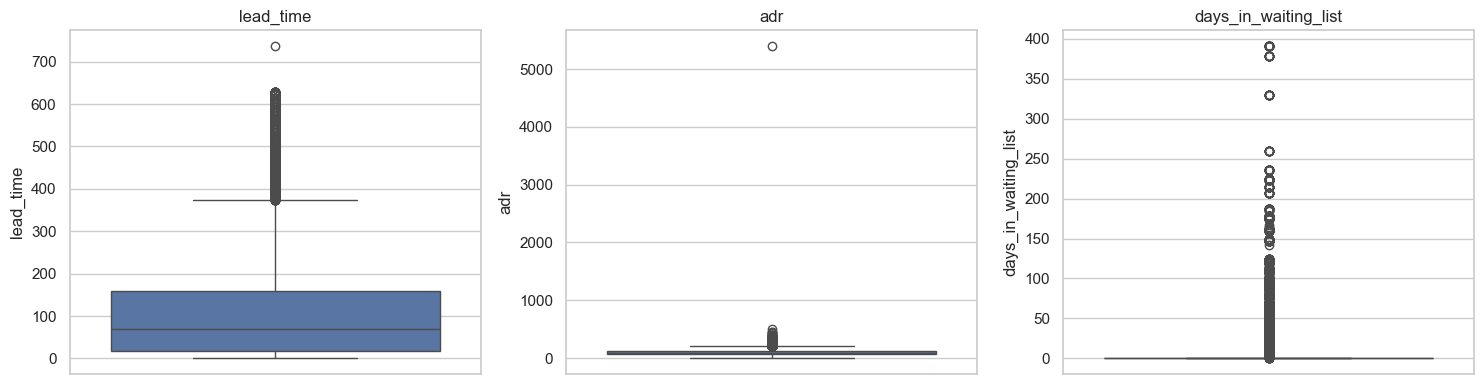

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.boxplot(y=df['lead_time'], ax=axes[0]); axes[0].set_title('lead_time')
sns.boxplot(y=df['adr'], ax=axes[1]); axes[1].set_title('adr')
sns.boxplot(y=df['days_in_waiting_list'], ax=axes[2]); axes[2].set_title('days_in_waiting_list')
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/outliers_boxplots.png', dpi=100)
plt.show()

In [13]:
def iqr_outlier_pct(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    return ((series < lower) | (series > upper)).mean() * 100

for col in ['lead_time', 'adr', 'days_in_waiting_list']:
    print(f'{col}: {iqr_outlier_pct(df[col]):.2f}% outliers (IQR)')

lead_time: 2.50% outliers (IQR)
adr: 3.14% outliers (IQR)
days_in_waiting_list: 3.11% outliers (IQR)


In [14]:
print('adr max:', df['adr'].max())
print('adr min:', df['adr'].min())
df[df['adr'] < 0][['adr','hotel','is_canceled']]

adr max: 5400.0
adr min: -6.38


,adr,hotel,is_canceled
60681,-6.38,Resort Hotel,0


**Conclusión outliers:**
- `adr` (precio medio diario) tiene un valor negativo anómalo y un extremo muy alto — candidatos a revisar/capear en preprocessing (posible error de registro).
- `lead_time` y `days_in_waiting_list` tienen cola larga a la derecha (right-skewed) pero son valores de negocio plausibles (reservas con mucha antelación) — no se recomienda eliminarlos, sí valorar transformación log para modelos lineales.


## Resumen de hallazgos para preprocessing

1. **Eliminar `reservation_status` y `reservation_status_date`** — data leakage directo del target.
2. **Missings de `company`/`agent`** son informativos ("sin agencia"), no imputar con estadísticos, tratar como categoría propia o indicador binario.
3. **`country`** (0.4%) y **`children`** (0.004%) — imputación simple (moda / mediana).
4. **Features más predictivas identificadas:** `lead_time`, `deposit_type`, `market_segment`, `previous_cancellations`, `country`.
5. **`adr`**: valor negativo y outliers extremos a revisar/capear.
6. **Target desbalanceado (63/37)** — usar `class_weight='balanced'`, `stratify` en CV, evitar Accuracy como métrica única.

## 4 · Feature Engineering & Preprocesado

*(Desarrollado originalmente en `src/notebooks/preprocessing.ipynb`)*

# Preprocessing — Hotel Booking Cancellation

Preprocesado y feature engineering sobre `train.csv`/`test.csv`. Todos los parámetros de imputación, encoding y escalado se ajustan (fit) exclusivamente sobre train y se aplican (transform) sobre test.

In [15]:
import pandas as pd
import numpy as np
import joblib
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

train_df = pd.read_csv('src/data_sample/train.csv')
test_df = pd.read_csv('src/data_sample/test.csv')
train_df.shape, test_df.shape

((95512, 32), (23878, 32))

## Paso 1: Eliminar columnas con data leakage

`reservation_status` y `reservation_status_date` determinan `is_canceled` de forma directa (detectado en EDA) — se eliminan sí o sí antes de cualquier entrenamiento.

In [16]:
LEAKAGE_COLS = ['reservation_status', 'reservation_status_date']
train_df = train_df.drop(columns=LEAKAGE_COLS)
test_df = test_df.drop(columns=LEAKAGE_COLS)
assert not any(c in train_df.columns for c in LEAKAGE_COLS)
print('columnas leakage eliminadas de train y test')

columnas leakage eliminadas de train y test


## Paso 2: Duplicados

Se eliminan duplicados exactos en train (calidad de datos). Test se deja intacto para no alterar el conjunto de evaluación.

In [17]:
dups = train_df.duplicated().sum()
print(f'duplicados en train: {dups}')
train_df = train_df.drop_duplicates().reset_index(drop=True)
train_df.shape

duplicados en train: 24463


(71049, 30)

## Paso 3: Feature engineering

- `has_agent`: indicador binario de si la reserva vino con agente (el missing en `agent` es informativo, visto en EDA).
- `has_company`: indicador binario equivalente para `company` (94.3% missing, se elimina la columna original por escaso valor más allá del indicador).
- `total_nights`: noches totales (weekend + week).
- `total_guests`: adultos + niños + bebés.

In [18]:
def feature_engineer(df):
    df = df.copy()
    df['has_agent'] = df['agent'].notna().astype(int)
    df['has_company'] = df['company'].notna().astype(int)
    df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
    df['total_guests'] = df['adults'] + df['children'].fillna(0) + df['babies']
    df = df.drop(columns=['agent', 'company'])
    return df

train_df = feature_engineer(train_df)
test_df = feature_engineer(test_df)
train_df[['has_agent','has_company','total_nights','total_guests']].describe()

,has_agent,has_company,total_nights,total_guests
count,71049.000000,71049.000000,71049.000000,71049.000000
mean,0.861588,0.059635,3.621726,2.020338
std,0.345334,0.236811,2.756847,0.795137
min,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,2.000000,2.000000
50%,1.000000,0.000000,3.000000,2.000000
75%,1.000000,0.000000,5.000000,2.000000
max,1.000000,1.000000,69.000000,55.000000


## Paso 4: Tratamiento de outliers en `adr`

EDA detectó un valor negativo (-6.38) y un extremo muy alto (5400) en `adr`. Se capea (winsoriza) usando percentiles 1 y 99 calculados **solo sobre train**, y se aplican los mismos límites a test.

In [19]:
lower = train_df['adr'].quantile(0.01)
upper = train_df['adr'].quantile(0.99)
print(f'limites adr (train): [{lower:.2f}, {upper:.2f}]')

train_df['adr'] = train_df['adr'].clip(lower, upper)
test_df['adr'] = test_df['adr'].clip(lower, upper)
train_df['adr'].describe()

limites adr (train): [0.00, 260.26]


count    71049.000000
mean       105.628216
std         50.519467
min          0.000000
25%         72.000000
50%         98.000000
75%        133.300000
max        260.260000
Name: adr, dtype: float64

## Paso 5: Agrupar categorías de alta cardinalidad en `country`

`country` tiene demasiadas categorías para one-hot directo. Se conservan las 15 más frecuentes (calculadas sobre train) y el resto se agrupa como `Other`.

In [20]:
top_countries = train_df['country'].value_counts().head(15).index.tolist()
print(top_countries)

def group_country(df):
    df = df.copy()
    df['country'] = df['country'].where(df['country'].isin(top_countries), 'Other')
    return df

train_df = group_country(train_df)
test_df = group_country(test_df)
train_df['country'].value_counts()

['PRT', 'GBR', 'FRA', 'ESP', 'DEU', 'ITA', 'IRL', 'BEL', 'BRA', 'NLD', 'USA', 'CHE', 'CN', 'AUT', 'SWE']


country
PRT      22341
GBR       8463
Other     7873
FRA       7200
ESP       5874
DEU       4409
ITA       2476
IRL       2424
BEL       1700
BRA       1615
NLD       1558
USA       1506
CHE       1272
CN         879
AUT        776
SWE        683
Name: count, dtype: int64

## Paso 6: Separar X/y y definir columnas por tipo

In [21]:
TARGET = 'is_canceled'
X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]
X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]

cat_cols = X_train.select_dtypes(include=['object','str']).columns.tolist()
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
print('categoricas:', cat_cols)
print('numericas:', num_cols)

categoricas: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']
numericas: ['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'has_agent', 'has_company', 'total_nights', 'total_guests']


## Paso 7: Pipeline de imputación + encoding + escalado

- Numéricas: imputación por mediana + `StandardScaler`.
- Categóricas: imputación por moda + `OneHotEncoder` (nominal, sin orden).
- Todo el `fit` se hace sobre train; test solo se transforma.

In [22]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols),
])

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)
X_train_proc.shape, X_test_proc.shape

((71049, 98), (23878, 98))

In [23]:
feature_names = preprocessor.get_feature_names_out()
X_train_final = pd.DataFrame(X_train_proc, columns=feature_names)
X_test_final = pd.DataFrame(X_test_proc, columns=feature_names)
X_train_final.shape, X_test_final.shape

((71049, 98), (23878, 98))

## Paso 8: Guardar datasets procesados y transformador

In [24]:
X_train_final.to_csv('src/data_sample/X_train.csv', index=False)
X_test_final.to_csv('src/data_sample/X_test.csv', index=False)
y_train.to_csv('src/data_sample/y_train.csv', index=False)
y_test.to_csv('src/data_sample/y_test.csv', index=False)

joblib.dump(preprocessor, 'src/models/preprocessor.joblib')
print('guardados: X_train.csv, X_test.csv, y_train.csv, y_test.csv, models/preprocessor.joblib')

guardados: X_train.csv, X_test.csv, y_train.csv, y_test.csv, models/preprocessor.joblib


## Resumen para modelado

- `X_train.csv` / `X_test.csv`: features numéricas escaladas + categóricas one-hot, listas para entrenar (sin fugas — encoder/scaler ajustados solo en train).
- `y_train.csv` / `y_test.csv`: target `is_canceled`.
- `src/models/preprocessor.joblib`: `ColumnTransformer` ajustado, reutilizable para inferencia sobre datos nuevos.
- Eliminadas: `reservation_status`, `reservation_status_date` (leakage), `agent`, `company` (sustituidas por indicadores `has_agent`/`has_company`).
- Nuevas features: `has_agent`, `has_company`, `total_nights`, `total_guests`.
- `adr` capeado a percentiles [1, 99] de train.

## 5 · Modelado, Optimización y Evaluación

*(Desarrollado originalmente en `src/notebooks/modelado.ipynb`)*

## 0 · Imports

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os

from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, RandomizedSearchCV)
from sklearn.preprocessing import OrdinalEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, classification_report,
                             ConfusionMatrixDisplay, RocCurveDisplay)

RANDOM_STATE = 42   # el MISMO que usará A en el split
pd.set_option("display.max_columns", None)

## 1 · Preprocesado


In [26]:
# Datos definitivos (preprocesado de Nil — feature/preprocessing)
X_train = pd.read_csv("src/data_sample/X_train.csv")
X_test = pd.read_csv("src/data_sample/X_test.csv")
y_train = pd.read_csv("src/data_sample/y_train.csv").squeeze()
y_test = pd.read_csv("src/data_sample/y_test.csv").squeeze()

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("Balance train:", round(y_train.mean(), 3), "| test:", round(y_test.mean(), 3))

X_train: (71049, 98) | X_test: (23878, 98)
Balance train: 0.275 | test: 0.37


### 1.1 · Verificación anti-fuga

In [27]:
prohibidas = ["reservation_status", "reservation_status_date"]
fugas = [c for c in prohibidas if c in X_train.columns]
assert not fugas, f"¡FUGA! Elimina estas columnas: {fugas}"
assert X_train.isna().sum().sum() == 0, "Quedan NaN en X_train"
print("OK — sin columnas de fuga y sin NaN")

OK — sin columnas de fuga y sin NaN


## 2 · Métrica de evaluación

**F1** como métrica principal: las clases están desbalanceadas (~37 % de cancelaciones),
así que la accuracy premiaría a un modelo que casi siempre dijera "no cancela". Al hotel le
importan los dos errores (no detectar una cancelación real, y molestar a un cliente que sí
vendrá con confirmaciones innecesarias), por lo que F1, que equilibra precision y recall,
es la métrica más honesta. Reportamos recall como secundaria por su valor operativo.

## 3 · Modelo baseline

In [28]:
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
pred = dummy.predict(X_test)

print("Accuracy baseline:", round(accuracy_score(y_test, pred), 3))
print("F1 baseline:      ", round(f1_score(y_test, pred), 3))
# Se espera F1 ~ 0: el baseline no acierta ninguna cancelación. Cualquier modelo real debe superarlo.

Accuracy baseline: 0.63
F1 baseline:       0.0


## 4 · Comparativa de modelos (validación cruzada)

Varios algoritmos con parámetros por defecto, comparados con CV estratificada **solo sobre train**.
SVM se omite a propósito: con ~120 k filas sería demasiado lento.

In [30]:
modelos = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "DecisionTree":       DecisionTreeClassifier(random_state=RANDOM_STATE),
    "RandomForest":       RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    "GradientBoosting":   GradientBoostingClassifier(random_state=RANDOM_STATE),
    "KNN":                KNeighborsClassifier(n_jobs=-1),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

filas = []
for nombre, modelo in modelos.items():
    scores = cross_val_score(modelo, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
    filas.append({"modelo": nombre, "f1_medio": scores.mean(), "std": scores.std()})
    print(f"{nombre:20s} F1 = {scores.mean():.3f} (+/- {scores.std():.3f})")

tabla = pd.DataFrame(filas).sort_values("f1_medio", ascending=False).reset_index(drop=True)
tabla

LogisticRegression   F1 = 0.561 (+/- 0.006)
DecisionTree         F1 = 0.615 (+/- 0.006)
RandomForest         F1 = 0.678 (+/- 0.005)
GradientBoosting     F1 = 0.627 (+/- 0.007)
KNN                  F1 = 0.595 (+/- 0.004)


,modelo,f1_medio,std
0,RandomForest,0.677992,0.005483
1,GradientBoosting,0.626570,0.006567
2,DecisionTree,0.615004,0.006362
3,KNN,0.594663,0.004475
4,LogisticRegression,0.561318,0.006026


### 4.1 · Gráfico de la comparativa

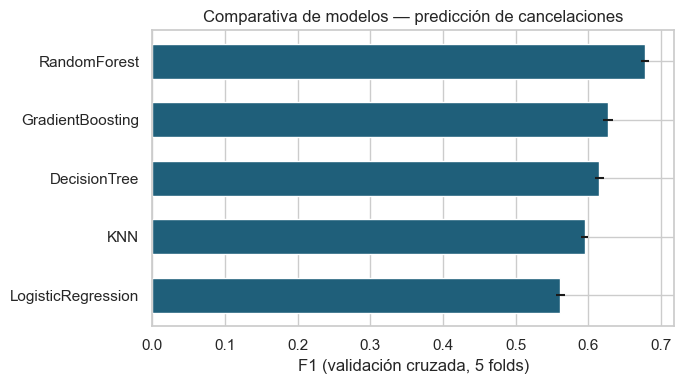

In [31]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(tabla["modelo"], tabla["f1_medio"], xerr=tabla["std"], color="#1f5f7a", height=0.6)
ax.invert_yaxis()
ax.set_xlabel("F1 (validación cruzada, 5 folds)")
ax.set_title("Comparativa de modelos — predicción de cancelaciones")
plt.tight_layout()
os.makedirs("src/img", exist_ok=True)
plt.savefig("src/img/comparativa_modelos.png", dpi=150)
plt.show()

### 4.2 · Variante con balanceo de clases

Dado que se detectó una diferencia en la proporción de clases entre train (27.5%) y test (37%)
tras la eliminación de duplicados, se prueba una variante de RandomForest con `class_weight="balanced"`
para comprobar si mejora la detección de la clase minoritaria (cancelaciones).

In [32]:
# Variante con balanceo de clases, dado el desbalance train/test detectado
rf_balanced = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, class_weight="balanced")
scores_balanced = cross_val_score(rf_balanced, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
print("F1 con class_weight='balanced':", round(scores_balanced.mean(), 3))

F1 con class_weight='balanced': 0.678


**Conclusión:** el balanceo de clases (`class_weight="balanced"`) no mejora el F1 (0.678 vs ~0.68 del RandomForest sin balancear). Se descarta esta variante y se continúa la optimización con el RandomForest estándar.

## 5 · Optimización de hiperparámetros

`RandomizedSearchCV` sobre el mejor modelo de la comparativa.

In [33]:
param_dist = {
    "n_estimators":      [100, 200, 300, 400],
    "max_depth":         [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
    "max_features":      ["sqrt", "log2"],
}

busqueda = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=25, scoring="f1", cv=cv,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=1,
)
busqueda.fit(X_train, y_train)   # SOLO train

print("Mejores hiperparámetros:", busqueda.best_params_)
print("Mejor F1 en CV:        ", round(busqueda.best_score_, 3))

modelo_final = busqueda.best_estimator_

Fitting 5 folds for each of 25 candidates, totalling 125 fits


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warn

Mejores hiperparámetros: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
Mejor F1 en CV:         0.682


## 6 · Evaluación final contra test

Primera y **única** vez que tocamos el test. Este número es el rendimiento esperado en producción.

In [34]:
y_pred  = modelo_final.predict(X_test)
y_proba = modelo_final.predict_proba(X_test)[:, 1]

print("Accuracy: ", round(accuracy_score(y_test, y_pred), 3))
print("Precision:", round(precision_score(y_test, y_pred), 3))
print("Recall:   ", round(recall_score(y_test, y_pred), 3))
print("F1:       ", round(f1_score(y_test, y_pred), 3))
print("ROC-AUC:  ", round(roc_auc_score(y_test, y_proba), 3))
print()
print(classification_report(y_test, y_pred, target_names=["No cancela", "Cancela"]))



Accuracy:  0.887
Precision: 0.891
Recall:    0.791
F1:        0.838
ROC-AUC:   0.954

              precision    recall  f1-score   support

  No cancela       0.88      0.94      0.91     15033
     Cancela       0.89      0.79      0.84      8845

    accuracy                           0.89     23878
   macro avg       0.89      0.87      0.88     23878
weighted avg       0.89      0.89      0.89     23878



### 6.1 · Matriz de confusión

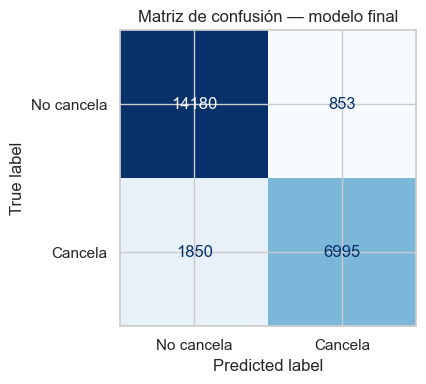

In [35]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(
    modelo_final, X_test, y_test, cmap="Blues", ax=ax, colorbar=False,
    display_labels=["No cancela", "Cancela"])
ax.set_title("Matriz de confusión — modelo final")
plt.tight_layout()
plt.savefig("src/img/matriz_confusion.png", dpi=150)
plt.show()

### 6.2 · Curva ROC

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


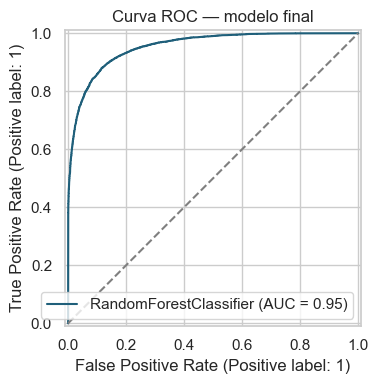

In [36]:
fig, ax = plt.subplots(figsize=(5, 4))
RocCurveDisplay.from_estimator(modelo_final, X_test, y_test, ax=ax, color="#1f5f7a")
ax.plot([0, 1], [0, 1], "--", color="gray")
ax.set_title("Curva ROC — modelo final")
plt.tight_layout()
plt.savefig("src/img/curva_roc.png", dpi=150)
plt.show()

## 7 · Interpretabilidad — variables más importantes

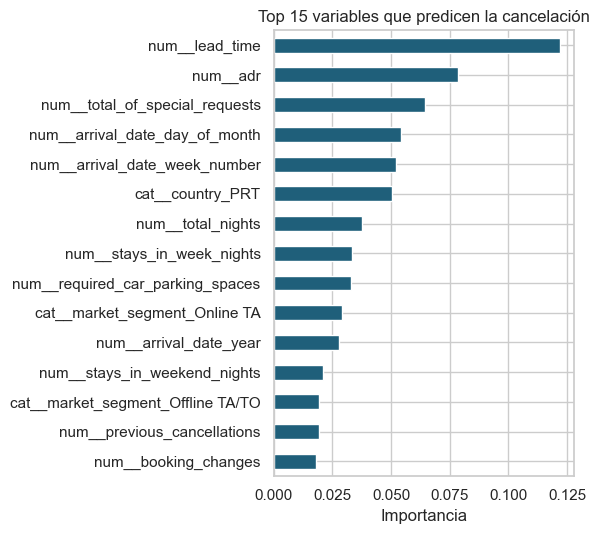

In [37]:
importancias = pd.Series(
    modelo_final.feature_importances_, index=X_train.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(6, 5.5))
importancias.tail(15).plot.barh(ax=ax, color="#1f5f7a")
ax.set_title("Top 15 variables que predicen la cancelación")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.savefig("src/img/feature_importance.png", dpi=150)
plt.show()

## 8 · Guardar el modelo (requisito de entrega)

In [38]:
os.makedirs("src/models", exist_ok=True)
joblib.dump(modelo_final, "src/models/modelo_cancelaciones.joblib", compress=3)

print("Modelo guardado en src/models/modelo_cancelaciones.joblib")

Modelo guardado en src/models/modelo_cancelaciones.joblib


## 9 · Conclusiones

- F1 final obtenido: **0.838** (frente a baseline ~0).
- El modelo detecta el **79.1 %** de las cancelaciones reales (recall).
- Impacto de negocio: permite reasignar / reconfirmar las reservas de riesgo.
- Limitaciones: datos de dos hoteles concretos y de 2015-2017; puede no generalizar. 
  Además, se detectó una diferencia en el balance de clases entre train (27.5%) y 
  test (37%) tras la eliminación de duplicados en el preprocesado, lo cual pudo 
  influir ligeramente en el aprendizaje del modelo.
- Próximos pasos: ajustar el umbral para priorizar recall, reequilibrado de clases (SMOTE), más datos.

Con un recall del 79 % y precisión del 89 %, el modelo permite al hotel anticipar la 
mayoría de cancelaciones con pocas falsas alarmas, lo que sustenta decisiones de 
overbooking controlado y campañas de reconfirmación dirigidas a las reservas de mayor riesgo.

## Contraste final con el problema de negocio

Con un **F1 de 0.838**, un **recall del 79%** y una **precisión del 89%** sobre el conjunto de test, el modelo permite al hotel anticipar la gran mayoría de las cancelaciones reales generando pocas falsas alarmas. Esto sustenta decisiones concretas de negocio: overbooking controlado sobre las reservas de mayor riesgo y campañas de reconfirmación dirigidas, en lugar de tratar todas las reservas por igual.

**Limitaciones.** Los datos corresponden a dos hoteles concretos entre 2015 y 2017, por lo que el modelo podría no generalizar a otros mercados o periodos. Se detectó además una diferencia en el balance de clases entre train (27,5%) y test (37%) tras la eliminación de duplicados en el preprocesado, que pudo influir levemente en el aprendizaje del modelo.

**Próximos pasos.** Ajustar el umbral de decisión para priorizar aún más el recall, explorar reequilibrado de clases (SMOTE), e incorporar datos más recientes para mejorar la capacidad de generalización.